In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense , LSTM # 


In [2]:
df = pd.read_csv('Google_Stock_Price_Train.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [5]:
train_set = df.iloc[:,1:2].values

In [6]:
train_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [7]:
sc = MinMaxScaler()

In [8]:
train_set = sc.fit_transform(train_set)

In [9]:
train_set

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [10]:
x_train = train_set[0:1257]
y_train = train_set[1:1258]

In [11]:
model = Sequential()

In [12]:
model.add(LSTM(units = 4, activation = 'sigmoid', input_shape = (None,1)))
model.add(Dense(units = 1))

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [14]:
model.fit(x_train , y_train , batch_size = 32 , epochs = 250)

Epoch 1/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2791
Epoch 2/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 0.1965
Epoch 3/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1398 
Epoch 4/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1039 
Epoch 5/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0817 
Epoch 6/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0694 
Epoch 7/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0627 
Epoch 8/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0592 
Epoch 9/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0572 
Epoch 10/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0558 
Epoch 11/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0548 
Epoch 12/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0538 
Epoch 13/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0527 
Epoch 14/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0517 
Epoch 15/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - los

In [15]:
test = pd.read_csv('Google_Stock_Price_Test.csv')

In [16]:
test = test.iloc[:,1:2].values

In [18]:
test = sc.fit_transform(test)

In [19]:
tahmin = model.predict(test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


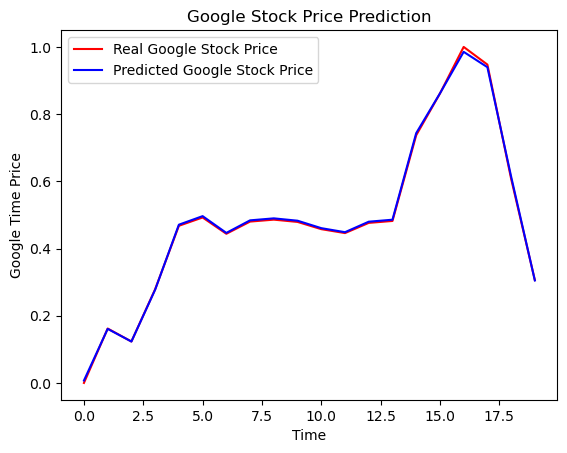

In [20]:
plt.plot(test , color = 'red' , label = 'Real Google Stock Price')
plt.plot(tahmin , color = 'blue' , label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Time Price')
plt.legend()
plt.show()